<a href="https://colab.research.google.com/github/imnaveenks/Movie-Success-Analysis/blob/main/Movie_Success_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
df = pd.read_csv('imdb_top_1000.csv')


In [5]:
df.head()        # first 5 rows
df.shape         # rows and columns
df.columns       # column names


Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [6]:
df.shape


(1000, 16)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [8]:
# Remove commas and convert Gross to a number
df['Gross'] = df['Gross'].str.replace(',', '')
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')

# Drop rows where Gross is missing
df_clean = df.dropna(subset=['Gross'])

print(df_clean.shape)


(831, 16)


In [9]:
df_clean['Gross'].describe()


,Gross
count,8.310000e+02
mean,6.803475e+07
std,1.097500e+08
min,1.305000e+03
25%,3.253559e+06
50%,2.353089e+07
75%,8.075089e+07
max,9.366622e+08


In [10]:
df_clean[df_clean['Gross'] == df_clean['Gross'].max()][['Series_Title', 'Gross']]


,Series_Title,Gross
477,Star Wars: Episode VII - The Force Awakens,936662225.0


In [11]:
df_clean[['Series_Title', 'Gross']].sort_values('Gross', ascending=False).head(10)


,Series_Title,Gross
477,Star Wars: Episode VII - The Force Awakens,936662225.0
59,Avengers: Endgame,858373000.0
623,Avatar,760507625.0
60,Avengers: Infinity War,678815482.0
652,Titanic,659325379.0
357,The Avengers,623279547.0
891,Incredibles 2,608581744.0
2,The Dark Knight,534858444.0
582,Rogue One,532177324.0
63,The Dark Knight Rises,448139099.0


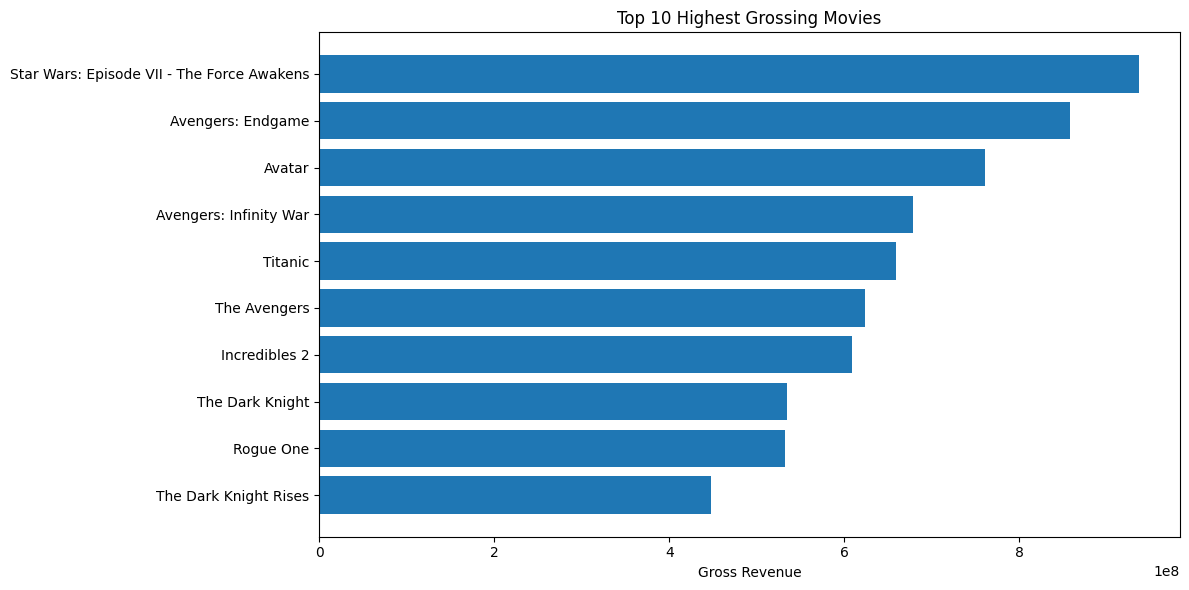

In [12]:
import matplotlib.pyplot as plt

top10 = df_clean[['Series_Title', 'Gross']].sort_values('Gross', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top10['Series_Title'], top10['Gross'])
plt.xlabel('Gross Revenue')
plt.title('Top 10 Highest Grossing Movies')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [14]:
df_clean = df_clean.copy()
df_clean['Main_Genre'] = df_clean['Genre'].str.split(',').str[0].str.strip()

genre_gross = df_clean.groupby('Main_Genre')['Gross'].mean().sort_values(ascending=False)

print(genre_gross)


Main_Genre
Family       2.195553e+08
Action       1.419631e+08
Animation    1.279675e+08
Adventure    8.645499e+07
Horror       7.358577e+07
Biography    6.012873e+07
Drama        3.867728e+07
Crime        3.419123e+07
Comedy       3.253759e+07
Mystery      3.043953e+07
Thriller     1.755074e+07
Western      1.455538e+07
Film-Noir    1.278626e+06
Name: Gross, dtype: float64


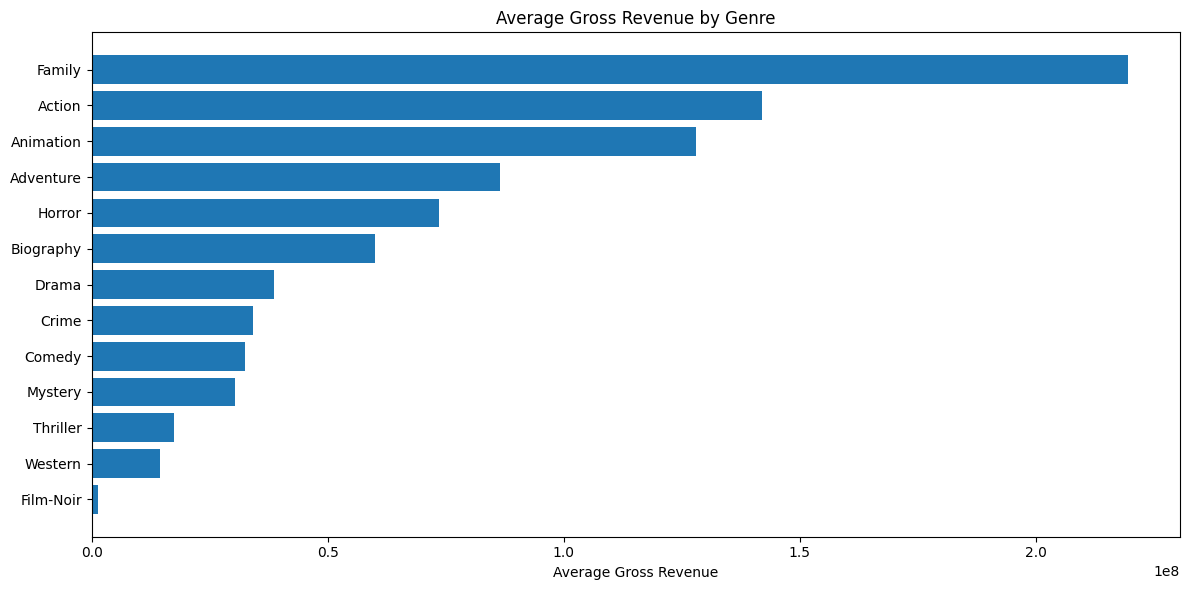

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.barh(genre_gross.index, genre_gross.values)
plt.xlabel('Average Gross Revenue')
plt.title('Average Gross Revenue by Genre')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


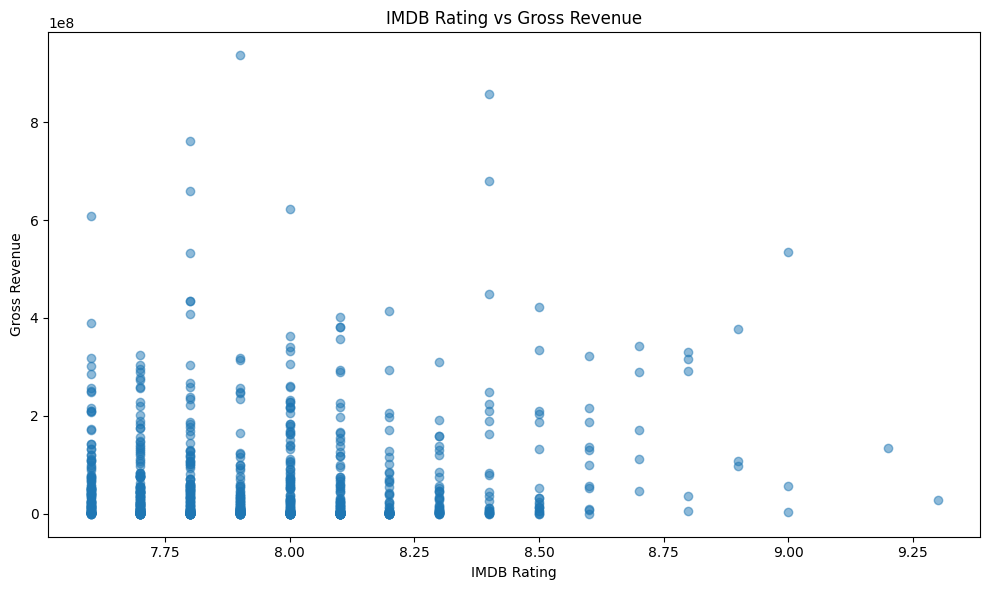

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['IMDB_Rating'], df_clean['Gross'], alpha=0.5)
plt.xlabel('IMDB Rating')
plt.ylabel('Gross Revenue')
plt.title('IMDB Rating vs Gross Revenue')
plt.tight_layout()
plt.show()


In [17]:
director_gross = df_clean.groupby('Director')['Gross'].mean().sort_values(ascending=False).head(10)

print(director_gross)


Director
Anthony Russo     5.512599e+08
Gareth Edwards    5.321773e+08
J.J. Abrams       4.743903e+08
Josh Cooley       4.340380e+08
Roger Allers      4.227838e+08
Tim Miller        3.630707e+08
James Gunn        3.614949e+08
James Cameron     3.496473e+08
Byron Howard      3.412682e+08
David Yates       3.263179e+08
Name: Gross, dtype: float64


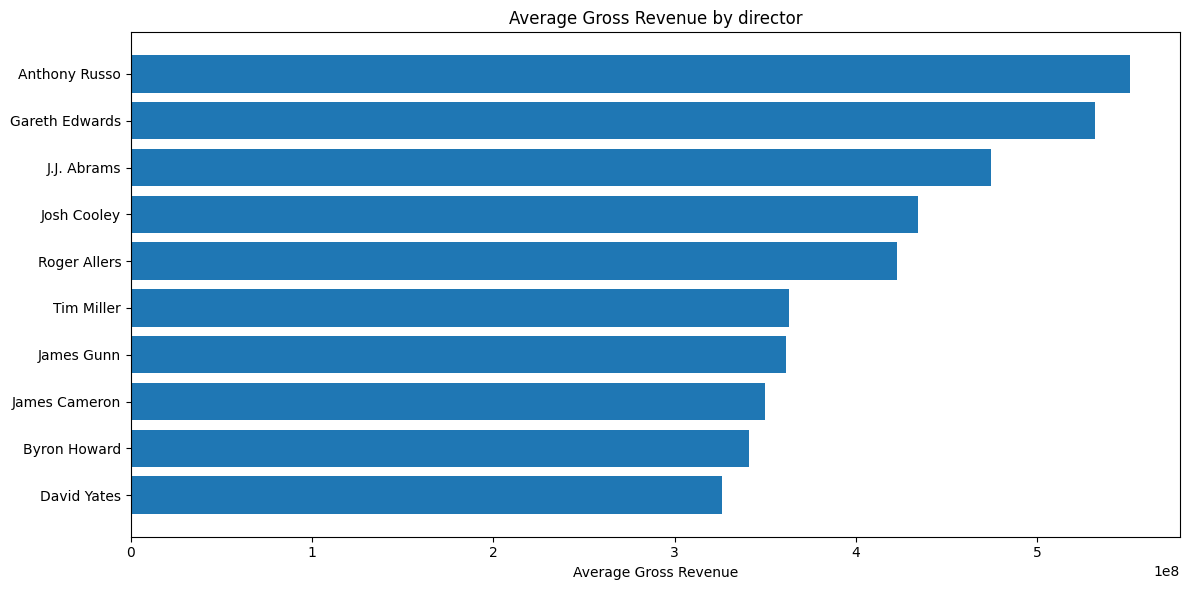

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.barh(director_gross.index, director_gross.values)
plt.xlabel('Average Gross Revenue')
plt.title('Average Gross Revenue by director')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
